In [4]:
# packages and working directory  
import scipy 
import sklearn
import econml 
import arch
import os 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib as plt
import statsmodels.api as sm 
from statsmodels.discrete.discrete_model import Probit
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf 
from scipy.optimize import minimize
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt 
from scipy import stats
from scipy.stats import ttest_ind
from scipy.optimize import approx_fprime
# Consolidate changing directory and CPI dictionary since these don't change throughout the script
new_directory = r'C:\Users\hisham\Spain\2021 datasets'
os.chdir(new_directory)


In [5]:
df = pd.read_csv('filtered.csv')
df.head()

,idhh,idperson,idmother,idfather,idpartner,idorighh,idorigperson,dag,dgn,dec,...,il_bsarg_63,il_bsarg_64,il_bsarg_70,scenario,original_scenario,choice_made,lhw_h0,lhw_h1,lhw_h2,lhw_h3
0,870100,87010001,0,0,87010002,870100,87010001,65,1,0,...,0.00,0.00,0.00,h0,h2,0,0,7,42,54
1,870600,87060001,0,0,0,870600,87060001,32,1,0,...,469.93,469.93,469.93,h0,h2,0,0,11,44,50
2,870700,87070001,0,0,0,870700,87070001,61,0,0,...,1747.61,1747.61,1747.61,h0,h0,1,0,7,27,52
3,870900,87090001,0,0,0,870900,87090001,33,0,0,...,100.00,100.00,100.00,h0,h2,0,0,10,37,51
4,871700,87170002,0,0,87170001,871700,87170002,61,0,0,...,312.50,312.50,312.50,h0,h2,0,0,7,40,51


In [6]:
def map_lhw(row):
    # Ensure the scenario prefix 'h' is included when constructing the column name
    scenario_prefix = 'h' if not row["scenario"].startswith('h') else ''
    scenario_column_name = f'lhw_{scenario_prefix}{row["scenario"]}'
    return row[scenario_column_name]

# Apply the corrected function
df['lhw_scenario'] = df.apply(map_lhw, axis=1)

# Print a sample to verify the column has been created correctly
print(df[['idperson', 'scenario', 'lhw_scenario']].head())


   idperson scenario  lhw_scenario
0  87010001       h0             0
1  87060001       h0             0
2  87070001       h0             0
3  87090001       h0             0
4  87170002       h0             0


In [10]:
# Identify individuals with any negative 'ils_udb_yds' values
negative_c_ids = df[df['ils_udb_yds'] < 0]['idperson'].unique()
# Identify individuals with any negative 'ils_udb_yds' values
negative_l_ids = df[df['lhw_scenario'] >= 80 ]['idperson'].unique()

# Filter df to exclude all rows belonging to individuals identified in step 1 or step 2
df_filtered = df[~df['idperson'].isin(negative_c_ids) & ~df['idperson'].isin(negative_l_ids)]



print(f"Number of individuals with negative leisure: {len(negative_l_ids)}")
print(f"Number of individuals with negative consumption: {len(negative_c_ids)}")
# Verify the removal
print(f"Original dataframe size: {df.shape}")
print(f"Filtered dataframe size: {df_filtered.shape}")

Number of individuals with negative leisure: 3
Number of individuals with negative consumption: 0
Original dataframe size: (18320, 350)
Filtered dataframe size: (18308, 350)


In [11]:
df_filtered['consum'] = np.log(df_filtered['ils_udb_yds'])

df_filtered['logleis'] = np.log(80 - df_filtered['lhw_scenario'])

print(df_filtered['consum'].describe())
print(df_filtered['logleis'].describe())


count    1.830800e+04
mean             -inf
std               NaN
min              -inf
25%      6.316171e+00
50%      7.040190e+00
75%      7.603046e+00
max      9.838603e+00
Name: consum, dtype: float64
count    18308.000000
mean         3.904408
std          0.459150
min          1.098612
25%          3.457799
50%          3.998159
75%          4.372593
max          4.382027
Name: logleis, dtype: float64


c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\1291338106.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['consum'] = np.log(df_filtered['ils_udb_yds'])
C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\1291338106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['logleis'] = np.log(80 - df_filtered[

In [14]:
# Identify individuals with any negative 'ils_udb_yds' values
negative_c_ids = df_filtered[df_filtered['consum'] < 0]['idperson'].unique()
# Identify individuals with any negative 'ils_udb_yds' values
negative_l_ids = df_filtered[df_filtered['logleis'] < 0]['idperson'].unique()


print(f"Number of individuals with negative leisure: {len(negative_l_ids)}")
print(f"Number of individuals with negative consumption: {len(negative_c_ids)}")


# Filter df to exclude all rows belonging to individuals identified in step 1 or step 2
df_filtered1 = df_filtered[~df_filtered['idperson'].isin(negative_c_ids) & ~df['idperson'].isin(negative_l_ids)]

# Verify the removal
print(f"Original dataframe size: {df_filtered.shape}")
print(f"Filtered dataframe size: {df_filtered1.shape}")


Number of individuals with negative leisure: 0
Number of individuals with negative consumption: 30
Original dataframe size: (18308, 352)
Filtered dataframe size: (18188, 352)


C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\1850400406.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered1 = df_filtered[~df_filtered['idperson'].isin(negative_c_ids) & ~df['idperson'].isin(negative_l_ids)]


In [15]:
# Jacobian 

def jacobian(params, df):
    epsilon = np.sqrt(np.finfo(float).eps)
    grad = approx_fprime(params, lambda p: total_likelihood(p,df ), epsilon)
    return grad

In [16]:
df_filtered1['logy'] = np.log(df_filtered1['ils_udb_yds'])

df_filtered1['logl'] = np.log( 80  - df_filtered1['lhw_scenario'])

df_filtered1['logy2'] = df_filtered1['logy'] ** 2 

df_filtered1['logl2'] = df_filtered1['logl'] ** 2 

df_filtered1['logyl'] = df_filtered1['logy'] * df_filtered1['logl'] 

df_filtered1 = df_filtered1.sort_values(by='idperson')


print(df_filtered1[['idperson', 'choice_made','lhw', 'lhw_scenario','scenario','logy','logy2','logl','logl2','logyl']])

        idperson  choice_made  lhw  lhw_scenario scenario      logy  \
0       87010001            0   42             0       h0  6.715868   
9160    87010001            1   42            42       h2  7.607476   
4580    87010001            0   42             7       h1  6.715868   
13740   87010001            0   42            54       h3  7.818157   
9161    87060001            1   44            44       h2  7.792056   
...          ...          ...  ...           ...      ...       ...   
4578   620080001            0   45             0       h0  6.301849   
9159   620120001            0   50             7       h1  6.283742   
4579   620120001            0   50             0       h0  6.283742   
13739  620120001            0   50            35       h2  7.153044   
18319  620120001            1   50            50       h3  7.460231   

           logy2      logl      logl2      logyl  
0      45.102885  4.382027  19.202157  29.429113  
9160   57.873688  3.637586  13.232033  27.672

C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\513504433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered1['logy'] = np.log(df_filtered1['ils_udb_yds'])
C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\513504433.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered1['logl'] = np.log( 80  - df_filtered1['lhw_scenario'])
C:\Users\hisham\AppData\Local\Temp\ipykernel_22344\513504433.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [17]:
## Trnslog 
def utility(params, row):
    # Unpacking parameters
    alpha, beta, gamma_yy, gamma_ll, gamma_yl = params[:5]
    # Calculating the logs of income and leisure
    log_y = row['logy']
    log_l = row['logl']
    log_y2 = row['logy2']
    log_l2 = row['logl2']
    logyl = row['logyl']
    # Translog utility function
    return alpha * log_y + beta * log_l + gamma_yy * log_y2 +  gamma_ll * log_l2 + gamma_yl * logyl

def ind_likelihood(params, group):
    utilities = group.apply(lambda row: utility(params, row), axis=1)
    chosen_utility = utilities[group['choice_made'] == 1].iloc[0] if any(group['choice_made'] == 1) else None
    if chosen_utility is not None:
        # Only consider scenarios where a choice is made
        log_prob_chosen = chosen_utility - logsumexp(utilities)
        return -log_prob_chosen  # Negative log likelihood
    else:
        return 0

def total_likelihood(params, df):
    # Grouping by individual and calculating likelihood per group
    total_ll = df.groupby('idperson').apply(lambda group: ind_likelihood(params, group)).sum()
    return total_ll


initial_params = [ 6.007e+01,  1.000e-01, -3.313e+00,  1.001e-02, -9.230e+00]  # Example: alpha, beta, gamma_yy, gamma_ll, gamma_yl



In [18]:

# Optimization
result = minimize(fun=total_likelihood, x0=initial_params, args=(df_filtered1,), method='BFGS')
print(result)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4161.491331462352
        x: [-1.238e+00  3.184e+01 -1.458e-03 -4.790e+00  6.176e-01]
      nit: 28
      jac: [ 1.221e-04  1.221e-04  2.380e-03  3.662e-04  3.662e-04]
 hess_inv: [[ 4.038e-03 -4.038e-03 ...  7.013e-05  2.689e-04]
            [-4.038e-03  4.038e-03 ... -7.013e-05 -2.689e-04]
            ...
            [ 7.013e-05 -7.013e-05 ...  1.733e-03 -1.779e-03]
            [ 2.689e-04 -2.689e-04 ... -1.779e-03  1.977e-03]]
     nfev: 330
     njev: 55


In [11]:
# Optimization
result1 = minimize(fun=total_likelihood, x0=initial_params, args=(df_filtered1,), method='BFGS')
print(result1)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4161.491331854071
        x: [-1.239e+00  3.184e+01 -1.410e-03 -4.790e+00  6.177e-01]
      nit: 20
      jac: [ 1.038e-03 -2.441e-04  1.355e-02 -2.014e-03  2.197e-03]
 hess_inv: [[ 1.632e+00 -3.619e-01 ...  1.298e-01 -7.874e-02]
            [-3.619e-01  1.003e-01 ... -2.305e-02  9.904e-03]
            ...
            [ 1.298e-01 -2.305e-02 ...  1.196e-02 -8.418e-03]
            [-7.874e-02  9.904e-03 ... -8.418e-03  6.839e-03]]
     nfev: 186
     njev: 31


In [14]:
df_filtered1['logl'][df_filtered1['choice_made']].mean()

df_filtered1['logy'][df_filtered1['choice_made']].mean()



6.720370580231571

In [43]:
# Automated calculation of points where marginal utilities become negative
mu_y_neg = np.exp(- (result1.x[0] + result1.x[4] * df_filtered1['logl'].mean()) / (2 * result1.x[2]))
mu_l_neg = np.exp(- (result1.x[1] + result1.x[4] * df_filtered1['logy'].mean()) / (2 * result1.x[3]))

print(f"Income level at which MU of income becomes negative: {mu_y_neg}")
print(f"Leisure level at which MU of leisure becomes negative: {mu_l_neg}")

Income level at which MU of income becomes negative: 3.779314490343118e+180
Leisure level at which MU of leisure becomes negative: 43.59796062288464


In [17]:
df_filtered1.to_stata('revissed4.dta')

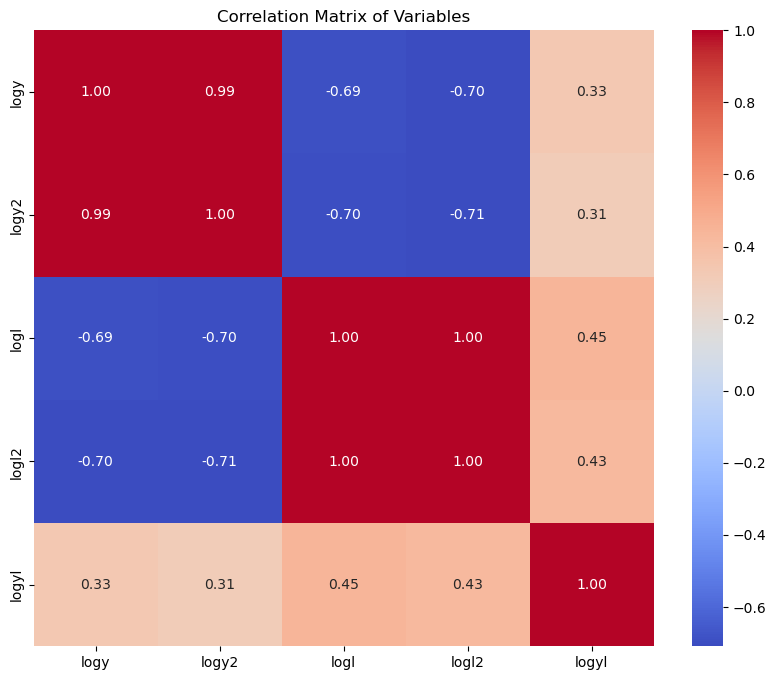

In [22]:
# Assuming 'df' is your DataFrame containing all relevant variables
features = ['logy', 'logy2', 'logl', 'logl2', 'logyl']  # Adjust this list to match your feature names
correlation_matrix = df_filtered1[features].corr()
correlation_matrix

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Variables')
plt.show()

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Adding a constant for the intercept term
X = df_filtered1[features]

# Calculating VIF for each feature
VIFs = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

print(VIFs)


  Variable          VIF
0     logy  7205.670228
1    logy2  1796.548359
2     logl  8771.576764
3    logl2  4227.608185
4    logyl  1907.081691


In [25]:
import numpy as np

# Standardizing the features
X_standardized = (df_filtered1[features] - df_filtered1[features].mean()) / df_filtered1[features].std()

# Performing PCA
U, s, Vt = np.linalg.svd(X_standardized, full_matrices=False)

# Calculating condition indices
condition_indices = np.sqrt(s.max() / s)

print("Condition Indices:", condition_indices)


Condition Indices: [1.         1.21155499 3.86314677 6.07953537 9.18087678]


In [56]:
params = [-1.239e+00,  3.184e+01, -1.410e-03, -4.790e+00,  6.177e-01]

In [61]:
df = df_filtered1.copy()

In [64]:

def utility_extended(params, row):
    alpha, beta, gamma_yy, gamma_ll, gamma_yl = params
    log_y = row['logy']
    log_l = row['logl']
    utility_value = alpha * log_y + beta * log_l + \
                     gamma_yy * (log_y**2) +  gamma_ll * (log_l**2) + \
                    gamma_yl * log_y * log_l
    mu_y = (alpha + 2 * gamma_yy * log_y + gamma_yl* log_l)
    mu_l = (beta + 2* gamma_ll * log_l + gamma_yl * log_y )
    return utility_value, mu_y, mu_l

# Calculate probabilities for each person based on utility values
def calculate_probabilities_corrected(group):
    utilities = group['utility'].values
    exp_utilities = np.exp(utilities - np.max(utilities))
    probabilities = exp_utilities / np.sum(exp_utilities)
    return pd.Series(probabilities, index=group.index)




In [66]:
df[['utility', 'mu_y', 'mu_l']] = df.apply(lambda row: utility_extended(params, row), axis=1, result_type="expand")
# Applying the function correctly
df['probability'] = df.groupby('idperson').apply(lambda group: calculate_probabilities_corrected(group)).reset_index(level=0, drop=True)


# Calculate the max probability for each group
max_probs = df.groupby('idperson')['probability'].transform('max')

# Assign predicted choice based on whether the probability equals the max probability within its group
df['predicted_choice'] = (df['probability'] == max_probs).astype(int)


In [67]:
# Assuming `df_filtered1` has columns: 'idperson', 'scenario', 'choice_made', 'predicted_choice'
# And 'scenario' column contains the scenario labels ('h0', 'h1', 'h2', 'h3')

# Marking actual choice scenarios (assuming 'choice_made' directly indicates this)
df['actual_choice'] = df.apply(lambda x: x['scenario'] if x['choice_made'] == 1 else None, axis=1)
df['actual_choice'] = df.groupby('idperson')['actual_choice'].ffill().bfill()

# Identifying the predicted choice scenario
df['predicted_choice_scenario'] = df.apply(lambda x: x['scenario'] if x['predicted_choice'] == 1 else None, axis=1)
df['predicted_choice_scenario'] = df.groupby('idperson')['predicted_choice_scenario'].ffill().bfill()

# Ensure there's no individual without a predicted scenario
assert df['predicted_choice_scenario'].isnull().sum() == 0, "Some individuals don't have a predicted scenario."


In [68]:
# First, ensure 'predicted_choice' is correctly assigned in 'df_filtered1'
# This step assumes you have a method to assign 'predicted_choice' correctly based on your model's output

# For simplicity, let's rebuild 'predicted_choice_scenario' based on the highest utility or probability
# Assuming 'utility' or 'probability' column exists in 'df_filtered1' indicating model output

# Step 1: Assign predicted choice scenario based on the highest utility or probability
# This method assumes 'utility' column exists; adjust accordingly if using probabilities
df['predicted_choice'] = df.groupby('idperson')['utility'].transform(lambda x: x == x.max())

# Now, each individual should have exactly one 'predicted_choice' flagged
# Let's try assigning 'predicted_choice_scenario' again
df['predicted_choice_scenario'] = df.apply(
    lambda x: x['scenario'] if x['predicted_choice'] else None, axis=1
)

# Fill missing 'predicted_choice_scenario' within each group
df['predicted_choice_scenario'] = df.groupby('idperson')['predicted_choice_scenario'].ffill().bfill()

# Verify the assignment
missing_predictions_post_fix = df[df['choice_made'] == 1]['predicted_choice_scenario'].isnull().sum()
if missing_predictions_post_fix > 0:
    raise AssertionError(f"Post-fix, still missing predictions for {missing_predictions_post_fix} individuals.")

# Assuming no error is raised, proceed with creating the comparison table
# This time, ensure to use the adjusted dataset where predicted scenarios are guaranteed to be assigned
actual_choices_df = df[df['choice_made'] == 1].copy()
comparison_table = pd.crosstab(
    actual_choices_df['actual_choice'],
    actual_choices_df['predicted_choice_scenario'],
    margins=True,
    margins_name='Total'
)

print(comparison_table)


predicted_choice_scenario  h1    h2  h3  Total
actual_choice                                 
h0                          0   199   6    205
h1                          3   475  17    495
h2                          0  3385   4   3389
h3                          0   447  11    458
Total                       3  4506  38   4547


In [25]:
df[['ils_udb_yds', 'lhw', 'original_scenario', 'lhw_h0','lhw_h1','lhw_h2','lhw_h3', 'yivwg']].describe()



,ils_udb_yds,lhw,lhw_h0,lhw_h1,lhw_h2,lhw_h3,yivwg
count,18320.000000,18320.000000,18320.0,18320.000000,18320.000000,18320.000000,18320.000000
mean,1466.713164,36.629913,0.0,11.141921,36.935371,53.761572,12.733555
std,1208.300741,12.553163,0.0,4.799507,5.149246,4.548785,8.851997
min,0.000000,0.000000,0.0,1.000000,26.000000,49.000000,0.010000
25%,553.372500,35.000000,0.0,7.000000,34.000000,50.000000,7.390000
50%,1141.040000,40.000000,0.0,9.000000,40.000000,52.000000,10.935000
75%,2003.965000,40.000000,0.0,14.000000,40.000000,56.000000,15.990000
max,18743.510000,99.000000,0.0,25.000000,48.000000,99.000000,140.800000
